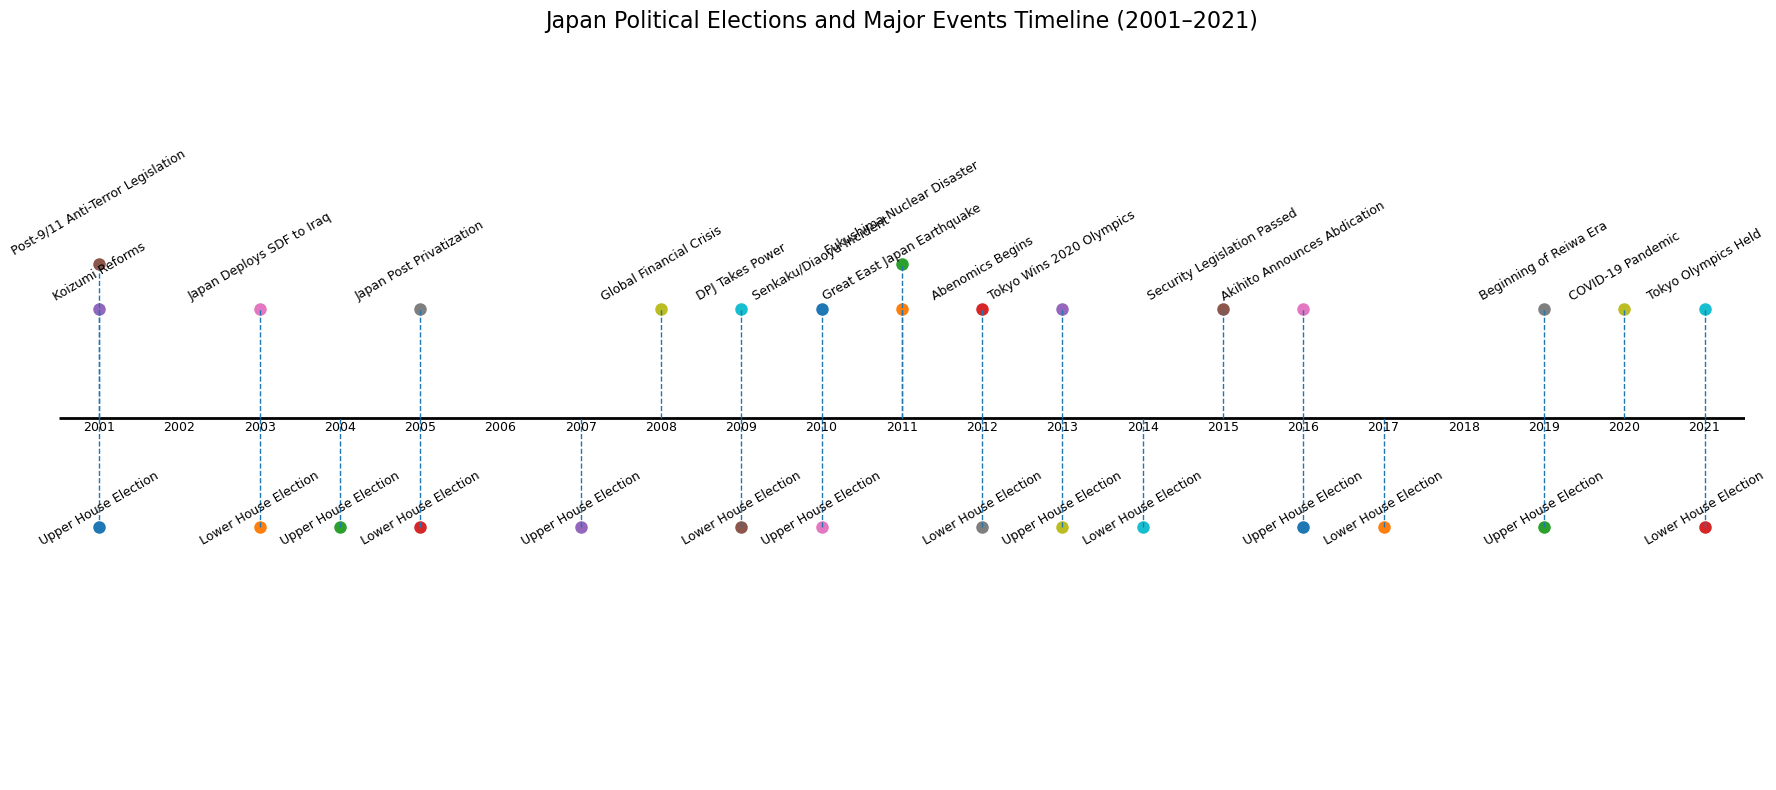

In [1]:
import matplotlib.pyplot as plt

# =========================
# DATA
# =========================

data = [
    # Elections
    (2001, "Election", "Upper House Election"),
    (2003, "Election", "Lower House Election"),
    (2004, "Election", "Upper House Election"),
    (2005, "Election", "Lower House Election"),
    (2007, "Election", "Upper House Election"),
    (2009, "Election", "Lower House Election"),
    (2010, "Election", "Upper House Election"),
    (2012, "Election", "Lower House Election"),
    (2013, "Election", "Upper House Election"),
    (2014, "Election", "Lower House Election"),
    (2016, "Election", "Upper House Election"),
    (2017, "Election", "Lower House Election"),
    (2019, "Election", "Upper House Election"),
    (2021, "Election", "Lower House Election"),

    # Events
    (2001, "Event", "Koizumi Reforms"),
    (2001, "Event", "Post-9/11 Anti-Terror Legislation"),
    (2003, "Event", "Japan Deploys SDF to Iraq"),
    (2005, "Event", "Japan Post Privatization"),
    (2008, "Event", "Global Financial Crisis"),
    (2009, "Event", "DPJ Takes Power"),
    (2010, "Event", "Senkaku/Diaoyu Incident"),
    (2011, "Event", "Great East Japan Earthquake"),
    (2011, "Event", "Fukushima Nuclear Disaster"),
    (2012, "Event", "Abenomics Begins"),
    (2013, "Event", "Tokyo Wins 2020 Olympics"),
    (2015, "Event", "Security Legislation Passed"),
    (2016, "Event", "Akihito Announces Abdication"),
    (2019, "Event", "Beginning of Reiwa Era"),
    (2020, "Event", "COVID-19 Pandemic"),
    (2021, "Event", "Tokyo Olympics Held"),
]

# =========================
# CREATE FIGURE
# =========================

fig, ax = plt.subplots(figsize=(18, 8))

# Main timeline line
ax.hlines(0, 2000.5, 2021.5, color='black', linewidth=2)

# =========================
# PLOT EVENTS + ELECTIONS
# =========================

event_offset = 1.2
election_offset = -1.2

event_counter = {}
election_counter = {}

for year, category, label in data:

    # EVENTS (TOP)
    if category == "Event":

        count = event_counter.get(year, 0)
        y = event_offset + (count * 0.5)

        ax.plot(year, y, 'o', markersize=8)
        ax.vlines(year, 0, y, linestyle='dashed', linewidth=1)

        ax.text(
            year,
            y + 0.1,
            label,
            ha='center',
            fontsize=9,
            rotation=30
        )

        event_counter[year] = count + 1

    # ELECTIONS (BOTTOM)
    elif category == "Election":

        count = election_counter.get(year, 0)
        y = election_offset - (count * 0.5)

        ax.plot(year, y, 'o', markersize=8)
        ax.vlines(year, y, 0, linestyle='dashed', linewidth=1)

        ax.text(
            year,
            y - 0.2,
            label,
            ha='center',
            fontsize=9,
            rotation=30
        )

        election_counter[year] = count + 1

# =========================
# YEAR LABELS
# =========================

years = list(range(2001, 2022))

for year in years:
    ax.text(year, -0.15, str(year), ha='center', fontsize=9)

# =========================
# STYLING
# =========================

ax.set_ylim(-4, 4)
ax.set_xlim(2000.5, 2021.5)

ax.set_title(
    "Japan Political Elections and Major Events Timeline (2001–2021)",
    fontsize=16,
    pad=20
)

# Remove axes
ax.axis('off')

# Layout
plt.tight_layout()

# =========================
# SAVE IMAGE
# =========================

plt.savefig("japan_timeline.png", dpi=300)

# Show chart
plt.show()

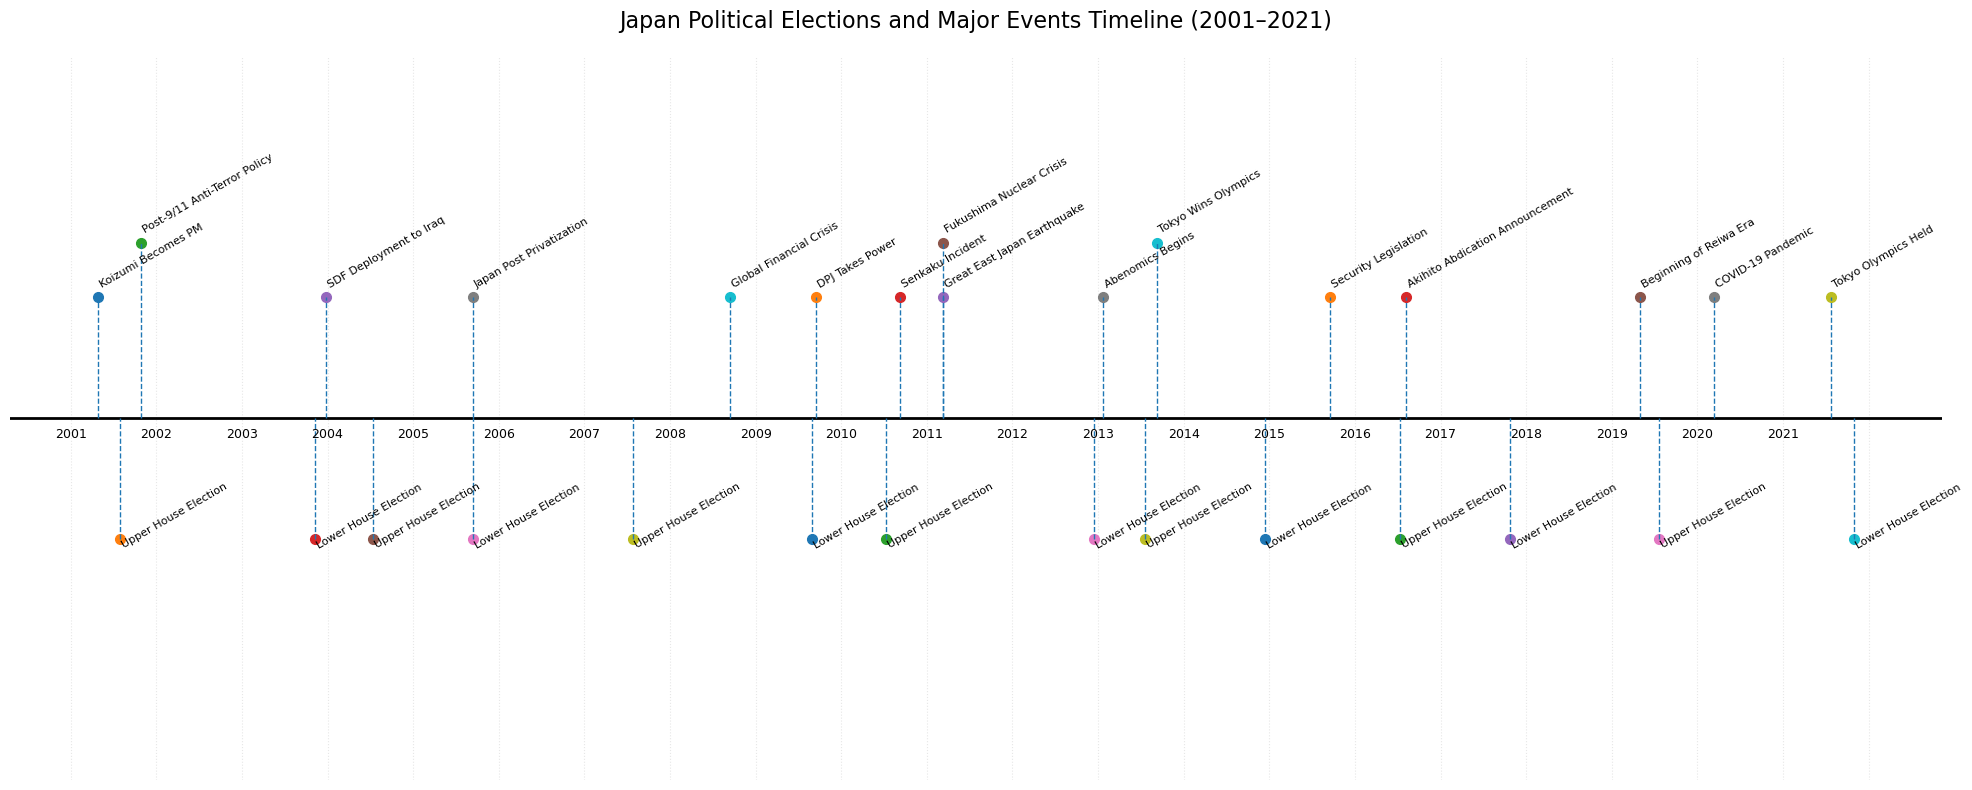

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ======================================
# DATA
# ======================================

data = [

    # Elections
    ("2001-07-29", "Election", "Upper House Election"),
    ("2003-11-09", "Election", "Lower House Election"),
    ("2004-07-11", "Election", "Upper House Election"),
    ("2005-09-11", "Election", "Lower House Election"),
    ("2007-07-29", "Election", "Upper House Election"),
    ("2009-08-30", "Election", "Lower House Election"),
    ("2010-07-11", "Election", "Upper House Election"),
    ("2012-12-16", "Election", "Lower House Election"),
    ("2013-07-21", "Election", "Upper House Election"),
    ("2014-12-14", "Election", "Lower House Election"),
    ("2016-07-10", "Election", "Upper House Election"),
    ("2017-10-22", "Election", "Lower House Election"),
    ("2019-07-21", "Election", "Upper House Election"),
    ("2021-10-31", "Election", "Lower House Election"),

    # Events
    ("2001-04-26", "Event", "Koizumi Becomes PM"),
    ("2001-10-29", "Event", "Post-9/11 Anti-Terror Policy"),
    ("2003-12-26", "Event", "SDF Deployment to Iraq"),
    ("2005-09-11", "Event", "Japan Post Privatization"),
    ("2006-10-09", "Event", "North Korea Nuclear Test"),
    ("2008-09-15", "Event", "Global Financial Crisis"),
    ("2009-09-16", "Event", "DPJ Takes Power"),
    ("2010-09-07", "Event", "Senkaku Incident"),
    ("2011-03-11", "Event", "Great East Japan Earthquake"),
    ("2011-03-12", "Event", "Fukushima Nuclear Crisis"),
    ("2013-01-22", "Event", "Abenomics Begins"),
    ("2013-09-07", "Event", "Tokyo Wins Olympics"),
    ("2015-09-19", "Event", "Security Legislation"),
    ("2016-08-08", "Event", "Akihito Abdication Announcement"),
    ("2017-08-29", "Event", "North Korean Missile Over Japan"),
    ("2018-12-08", "Event", "Major Immigration Reform"),
    ("2019-05-01", "Event", "Beginning of Reiwa Era"),
    ("2020-03-11", "Event", "COVID-19 Pandemic"),
    ("2021-07-23", "Event", "Tokyo Olympics Held"),
]

# ======================================
# CONVERT TO DATETIME
# ======================================

data = [
    (datetime.strptime(date, "%Y-%m-%d"), category, label)
    for date, category, label in data
]

data.sort(key=lambda x: x[0])

# ======================================
# FIGURE
# ======================================

fig, ax = plt.subplots(figsize=(20, 8))

# Main timeline
ax.axhline(0, color="black", linewidth=2)

# ======================================
# EVENTS
# ======================================

event_counter = {}
election_counter = {}

for date, category, label in data:

    year = date.year

    if category == "Event":

        count = event_counter.get(year, 0)
        y = 1.0 + count * 0.45

        ax.plot(date, y, "o", markersize=7)
        ax.vlines(date, 0, y, linestyle="dashed", linewidth=1)

        ax.text(
            date,
            y + 0.08,
            label,
            fontsize=8,
            rotation=30,
            ha="left"
        )

        event_counter[year] = count + 1

    else:

        count = election_counter.get(year, 0)
        y = -1.0 - count * 0.45

        ax.plot(date, y, "o", markersize=7)
        ax.vlines(date, y, 0, linestyle="dashed", linewidth=1)

        ax.text(
            date,
            y - 0.08,
            label,
            fontsize=8,
            rotation=30,
            ha="left"
        )

        election_counter[year] = count + 1

# ======================================
# YEAR LABELS ON THE TIMELINE
# ======================================

# Keep year positions
ax.xaxis.set_major_locator(mdates.YearLocator())

# Hide normal x-axis
ax.set_xticklabels([])
ax.tick_params(axis='x', length=0)

# Custom year labels just below timeline
for year in range(2001, 2022):

    ax.text(
        datetime(year, 1, 1),
        -0.08,      # move closer/farther from timeline
        str(year),
        ha='center',
        va='top',
        fontsize=9
    )

# Optional guide lines
ax.grid(
    axis='x',
    linestyle=':',
    alpha=0.3
)

# ======================================
# STYLING
# ======================================

ax.set_ylim(-3, 3)

ax.set_title(
    "Japan Political Elections and Major Events Timeline (2001–2021)",
    fontsize=16,
    pad=20
)

ax.set_yticks([])

# Remove borders
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# ======================================
# SAVE
# ======================================

plt.tight_layout()

plt.savefig(
    "japan_timeline_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()